# Step 1: Problem Framing & Theory Notes

## 1. Why is Accuracy a Terrible Metric for Fraud Detection?

Accuracy is not a good metric because fraud datasets are highly imbalanced. Most transactions are legitimate, and only a very small percentage are fraudulent.

If **99.83%** of transactions are legitimate and the model predicts every transaction as **"Not Fraud"**:

- **Accuracy = 99.83%**
- **Precision (Fraud) = 0**
- **Recall (Fraud) = 0**

Although the accuracy is very high, the model fails to detect any fraud, making it useless in real-world fraud detection.

---

## 2. What is the Precision-Recall Tradeoff?

**Precision** measures how many predicted fraud transactions are actually fraud.

**Recall** measures how many actual fraud transactions are correctly detected.

### Confusion Matrix

|               | Predicted Legit | Predicted Fraud |
|---------------|-----------------|-----------------|
| Actual Legit  | TN              | FP              |
| Actual Fraud  | FN              | TP              |

When the classification threshold is reduced from **0.5 to 0.2**:

- More transactions are classified as fraud.
- **Recall increases** because more fraud cases are detected.
- **Precision may decrease** because more legitimate transactions are incorrectly flagged as fraud.
- This creates a tradeoff between catching more fraud and reducing false alarms.

---

## 3. Three Strategies to Handle Class Imbalance

### (a) Random Undersampling
- Removes some majority-class (legitimate) samples.
- Simple and fast.
- May lose useful information.

### (b) SMOTE Oversampling
- Creates synthetic fraud samples.
- Improves class balance without losing data.
- May slightly increase training time.

### (c) Class Weight = Balanced
- Gives more importance to the minority (fraud) class.
- No need to change the dataset.
- Easy to implement and works well for many models.

---

## 4. What is PR-AUC? Why is it Preferred?

**PR-AUC (Precision-Recall Area Under Curve)** measures the balance between Precision and Recall across different thresholds.

It is preferred over ROC-AUC for highly imbalanced datasets because it focuses on the performance of the minority (fraud) class rather than the majority class.

A higher PR-AUC indicates better fraud detection performance.

---

## 5. Which is More Costly: False Positive or False Negative?

### False Positive (FP)
A legitimate transaction is incorrectly flagged as fraud.

**Business Impact:**
- Customer inconvenience
- Extra investigation cost
- Temporary transaction delay

### False Negative (FN)
A fraudulent transaction is predicted as legitimate.

**Business Impact:**
- Financial loss
- Customer trust issues
- Increased fraud risk

**Conclusion:**
A **False Negative** is generally much more costly because it allows fraud to go undetected and results in direct financial loss.

# STEP : 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("D:\Supervised Learning\SL_Final\creditcard.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Purvi\AppData\Local\Temp\ipykernel_22520\4260779429.py:1: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv("D:\Supervised Learning\SL_Final\creditcard.csv")


In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.shape

(284807, 31)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
284802    False
284803    False
284804    False
284805    False
284806    False
Length: 284807, dtype: bool

In [10]:
sample_df, _ = train_test_split(data,train_size=50000,stratify=data['Class'],random_state=42)

print(sample_df.shape)

(50000, 31)


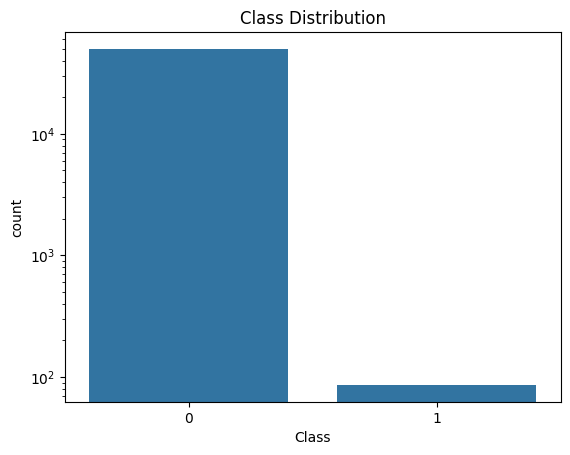

In [11]:
sns.countplot(x='Class', data=sample_df)
plt.yscale('log')
plt.title('Class Distribution')
plt.show()

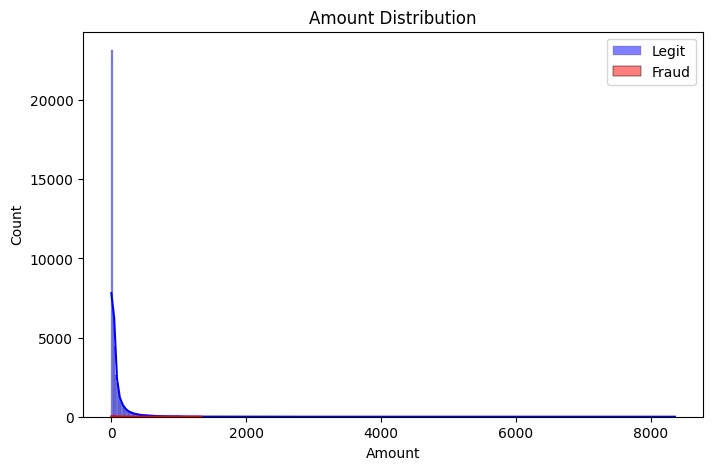

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(sample_df[sample_df['Class']==0]['Amount'],color='blue', label='Legit', kde=True)

sns.histplot(sample_df[sample_df['Class']==1]['Amount'],color='red', label='Fraud', kde=True)

plt.legend()
plt.title('Amount Distribution')
plt.show()

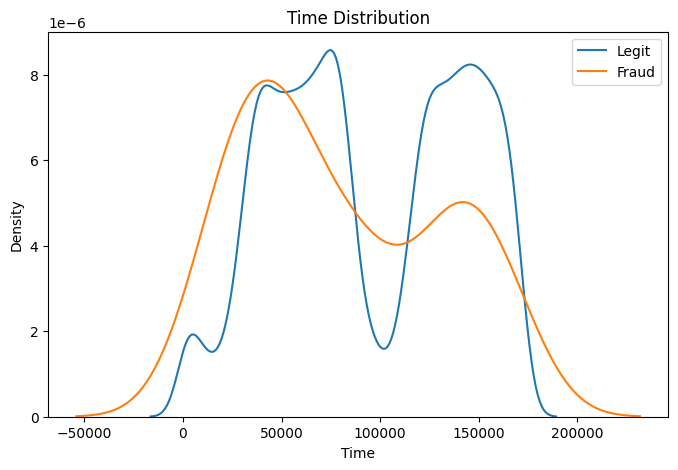

In [13]:
plt.figure(figsize=(8,5))

sns.kdeplot(sample_df[sample_df['Class']==0]['Time'],label='Legit')

sns.kdeplot(sample_df[sample_df['Class']==1]['Time'],label='Fraud')

plt.legend()
plt.title('Time Distribution')
plt.show()

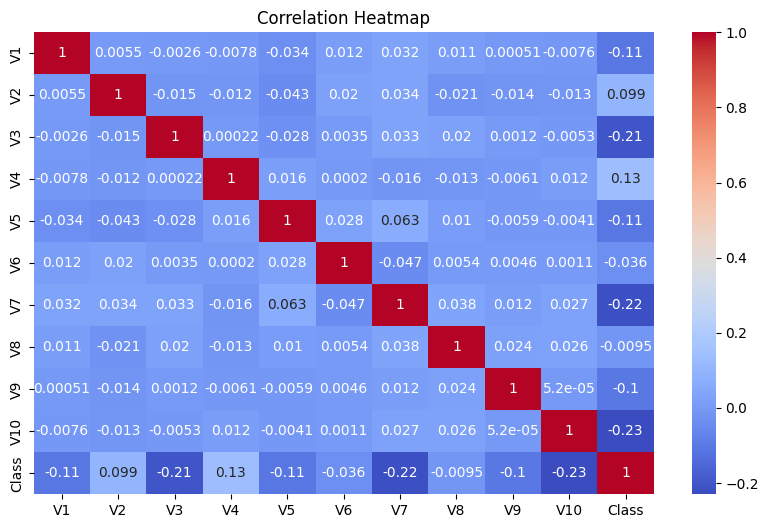

In [14]:
cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Class']

plt.figure(figsize=(10,6))
sns.heatmap(sample_df[cols].corr(),annot=True,cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [15]:
X = data.drop(["Amount", "Class"], axis=1)

y_class = data["Amount"]

y_reg = data["Class"]

# STEP : 3

In [16]:
sample_df['Amount_log'] = np.log1p(sample_df['Amount'])
sample_df['Hour'] = (sample_df['Time'] % 86400) // 3600

In [17]:
sample_df.drop(['Time', 'Amount'], axis=1, inplace=True)

sample_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
29784,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,3.671479,9.0
196949,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,3.660737,12.0
137061,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,4.262680,22.0
53715,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,4.987025,12.0
42739,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,0.693147,11.0


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

sample_df[['Amount_log', 'Hour']] = scaler.fit_transform(sample_df[['Amount_log', 'Hour']])

In [19]:
from sklearn.model_selection import train_test_split

X = sample_df.drop('Class', axis=1)
y = sample_df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

In [20]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

Test:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [22]:
print(y_train.value_counts())

Class
0    39931
1       69
Name: count, dtype: int64


In [23]:
smote = SMOTE(sampling_strategy=0.1,random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(y_smote.value_counts())

Class
0    39931
1     3993
Name: count, dtype: int64


In [24]:
under = RandomUnderSampler(sampling_strategy=0.1,random_state=42)

X_under, y_under = under.fit_resample(X_train, y_train)

print(y_under.value_counts())

Class
0    690
1     69
Name: count, dtype: int64


In [25]:
print("Original:\n", y_train.value_counts())
print("\nSMOTE:\n", y_smote.value_counts())
print("\nUndersampled:\n", y_under.value_counts())

Original:
 Class
0    39931
1       69
Name: count, dtype: int64

SMOTE:
 Class
0    39931
1     3993
Name: count, dtype: int64

Undersampled:
 Class
0    690
1     69
Name: count, dtype: int64


# STEP : 4

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score


In [27]:
lr_original = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)

lr_original.fit(X_train, y_train)

y_pred1 = lr_original.predict(X_test)
y_prob1 = lr_original.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred1))
print("PR-AUC:", average_precision_score(y_test, y_prob1))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9983
           1       0.07      1.00      0.12        17

    accuracy                           0.98     10000
   macro avg       0.53      0.99      0.55     10000
weighted avg       1.00      0.98      0.99     10000

PR-AUC: 0.7811395995154227


In [28]:
lr_smote = LogisticRegression(max_iter=1000,random_state=42)

lr_smote.fit(X_smote, y_smote)

y_pred2 = lr_smote.predict(X_test)
y_prob2 = lr_smote.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred2))
print("PR-AUC:", average_precision_score(y_test, y_prob2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.31      1.00      0.47        17

    accuracy                           1.00     10000
   macro avg       0.65      1.00      0.74     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.813276782412327


In [29]:
lr_under = LogisticRegression(max_iter=1000,random_state=42)

lr_under.fit(X_under, y_under)

y_pred3 = lr_under.predict(X_test)
y_prob3 = lr_under.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred3))
print("PR-AUC:", average_precision_score(y_test, y_prob3))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9983
           1       0.23      0.94      0.37        17

    accuracy                           0.99     10000
   macro avg       0.61      0.97      0.68     10000
weighted avg       1.00      0.99      1.00     10000

PR-AUC: 0.8128361353129155


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({'Model':['Original','SMOTE','Undersample'],
    'Precision':[
        precision_score(y_test,y_pred1),
        precision_score(y_test,y_pred2),
        precision_score(y_test,y_pred3)
    ],
    'Recall':[
        recall_score(y_test,y_pred1),
        recall_score(y_test,y_pred2),
        recall_score(y_test,y_pred3)
    ],
    'F1':[
        f1_score(y_test,y_pred1),
        f1_score(y_test,y_pred2),
        f1_score(y_test,y_pred3)
    ],
    'PR-AUC':[
        average_precision_score(y_test,y_prob1),
        average_precision_score(y_test,y_prob2),
        average_precision_score(y_test,y_prob3)
    ]
})

results

,Model,Precision,Recall,F1,PR-AUC
0,Original,0.065134,1.000000,0.122302,0.781140
1,SMOTE,0.309091,1.000000,0.472222,0.813277
2,Undersample,0.228571,0.941176,0.367816,0.812836


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)

rf.fit(X_smote, y_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.93      0.82      0.88        17

    accuracy                           1.00     10000
   macro avg       0.97      0.91      0.94     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.8747799024385674


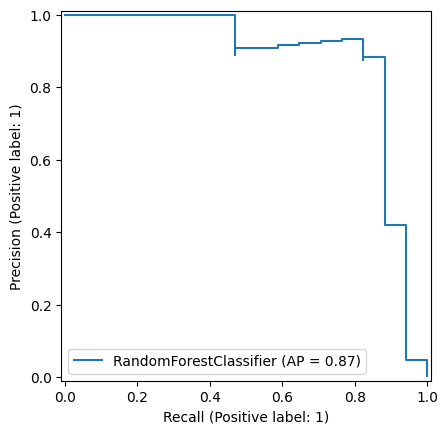

In [33]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)
plt.show()

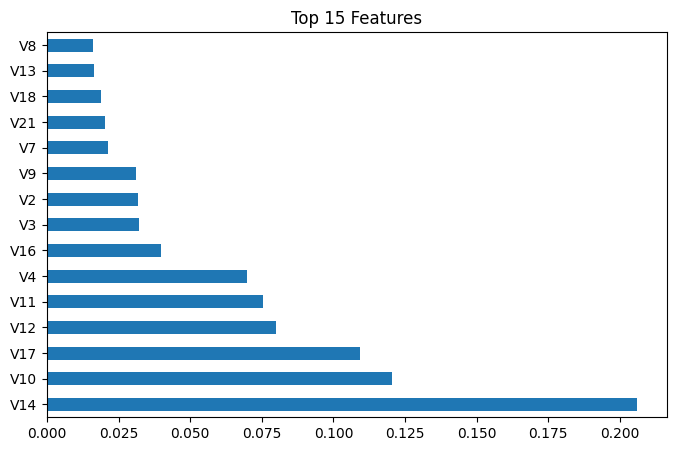

In [34]:
importance = pd.Series(rf.feature_importances_,index=X_train.columns)

importance.sort_values(ascending=False).head(15).plot(kind='barh',figsize=(8,5))

plt.title('Top 15 Features')
plt.show()

In [35]:
print(importance.sort_values(ascending=False).head(15))

V14    0.206167
V10    0.120345
V17    0.109266
V12    0.080050
V11    0.075564
V4     0.069819
V16    0.039787
V3     0.032188
V2     0.031850
V9     0.031054
V7     0.021430
V21    0.020333
V18    0.018958
V13    0.016412
V8     0.016136
dtype: float64


# STEP : 5

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score

In [37]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(ratio)

578.7101449275362


In [38]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42
)

xgb.fit(X_smote, y_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [39]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.60      0.88      0.71        17

    accuracy                           1.00     10000
   macro avg       0.80      0.94      0.86     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.8790231865253859


In [40]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.60      0.88      0.71        17

    accuracy                           1.00     10000
   macro avg       0.80      0.94      0.86     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.8790231865253859


In [41]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0]
}

In [42]:
search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=ratio,
        random_state=42
    ),
    param_distributions=params,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

search.fit(X_smote, y_smote)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [43]:
print("Best Parameters:")
print(search.best_params_)

print("Best CV PR-AUC:")
print(search.best_score_)

Best Parameters:
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC:
0.9998207704094199


In [44]:
best_xgb = search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_best))
print("PR-AUC:", average_precision_score(y_test, y_prob_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.58      0.88      0.70        17

    accuracy                           1.00     10000
   macro avg       0.79      0.94      0.85     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.8885984412862687


In [45]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_best
)

In [46]:
f1 = 2 * precision[:-1] * recall[:-1] / (
    precision[:-1] + recall[:-1]
)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best Threshold: 0.98885614
Best F1: 0.8749999999999999


In [47]:
y_pred_opt = (y_prob_best >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.93      0.82      0.88        17

    accuracy                           1.00     10000
   macro avg       0.97      0.91      0.94     10000
weighted avg       1.00      1.00      1.00     10000



In [48]:
idx = np.where(recall[:-1] >= 0.90)[0]

best_idx2 = idx[np.argmax(precision[:-1][idx])]
threshold_90 = thresholds[best_idx2]

print("Threshold:", threshold_90)
print("Precision:", precision[best_idx2])
print("Recall:", recall[best_idx2])

Threshold: 0.2827787
Precision: 0.5161290322580645
Recall: 0.9411764705882353


In [49]:
y_pred_90 = (y_prob_best >= threshold_90).astype(int)

print(classification_report(y_test, y_pred_90))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.52      0.94      0.67        17

    accuracy                           1.00     10000
   macro avg       0.76      0.97      0.83     10000
weighted avg       1.00      1.00      1.00     10000



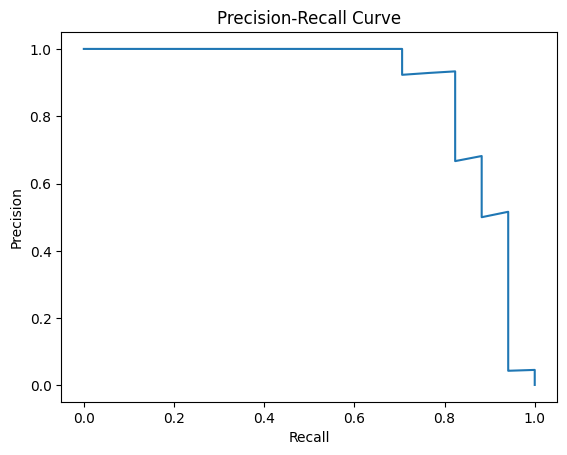

In [50]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# STEP : 6

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

In [52]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost Baseline",
        "XGBoost Tuned (0.5)",
        "XGBoost Tuned (Best F1)",
        "XGBoost Tuned (Recall>=0.90)"
    ],

    "Precision":[
        precision_score(y_test,y_pred2),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_best),
        precision_score(y_test,y_pred_opt),
        precision_score(y_test,y_pred_90)
    ],

    "Recall":[
        recall_score(y_test,y_pred2),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_best),
        recall_score(y_test,y_pred_opt),
        recall_score(y_test,y_pred_90)
    ],

    "F1":[
        f1_score(y_test,y_pred2),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_best),
        f1_score(y_test,y_pred_opt),
        f1_score(y_test,y_pred_90)
    ],

    "PR-AUC":[
        average_precision_score(y_test,y_prob2),
        average_precision_score(y_test,y_prob_rf),
        average_precision_score(y_test,y_prob),
        average_precision_score(y_test,y_prob_best),
        average_precision_score(y_test,y_prob_best),
        average_precision_score(y_test,y_prob_best)
    ],

    "Threshold":[
        0.5,
        0.5,
        0.5,
        0.5,
        round(best_threshold,2),
        round(threshold_90,2)
    ]
})

results

,Model,Precision,Recall,F1,PR-AUC,Threshold
0,Logistic Regression,0.309091,1.000000,0.472222,0.813277,0.50
1,Random Forest,0.933333,0.823529,0.875000,0.874780,0.50
2,XGBoost Baseline,0.600000,0.882353,0.714286,0.879023,0.50
3,XGBoost Tuned (0.5),0.576923,0.882353,0.697674,0.888598,0.50
4,XGBoost Tuned (Best F1),0.933333,0.823529,0.875000,0.888598,0.99
5,XGBoost Tuned (Recall>=0.90),0.516129,0.941176,0.666667,0.888598,0.28


In [53]:
from sklearn.metrics import PrecisionRecallDisplay

<Figure size 800x600 with 0 Axes>

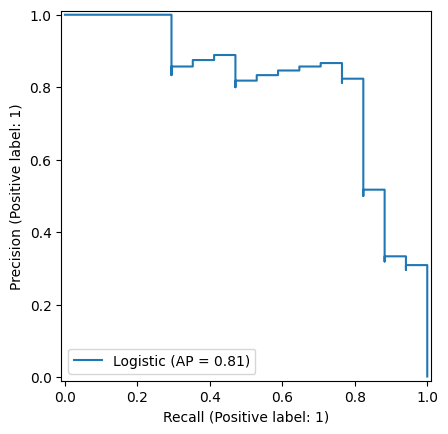

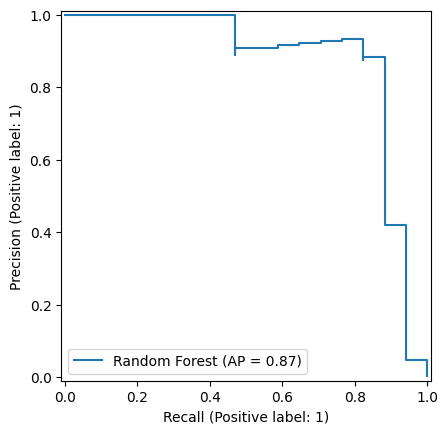

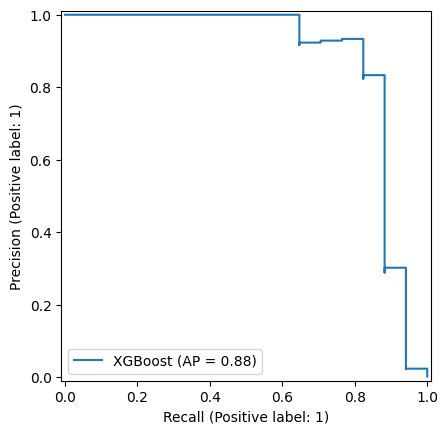

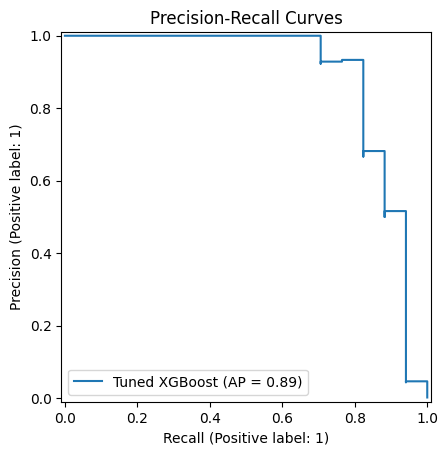

In [54]:
plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(y_test,y_prob2,name="Logistic")
PrecisionRecallDisplay.from_predictions(y_test,y_prob_rf,name="Random Forest")
PrecisionRecallDisplay.from_predictions(y_test,y_prob,name="XGBoost")
PrecisionRecallDisplay.from_predictions(y_test,y_prob_best,name="Tuned XGBoost")

plt.title("Precision-Recall Curves")
plt.show()

In [55]:
print(results.sort_values("PR-AUC", ascending=False))

                          Model  Precision    Recall        F1    PR-AUC  \
4       XGBoost Tuned (Best F1)   0.933333  0.823529  0.875000  0.888598   
3           XGBoost Tuned (0.5)   0.576923  0.882353  0.697674  0.888598   
5  XGBoost Tuned (Recall>=0.90)   0.516129  0.941176  0.666667  0.888598   
2              XGBoost Baseline   0.600000  0.882353  0.714286  0.879023   
1                 Random Forest   0.933333  0.823529  0.875000  0.874780   
0           Logistic Regression   0.309091  1.000000  0.472222  0.813277   

   Threshold  
4       0.99  
3       0.50  
5       0.28  
2       0.50  
1       0.50  
0       0.50  


Recommendation: The Tuned XGBoost model gives the best overall performance because it achieves the highest PR-AUC and F1-score for fraud detection. If the goal is to maximize fraud detection, the Best F1 Threshold is recommended as it balances precision and recall. If missing fraudulent transactions is very costly, the Recall ≥ 0.90 threshold is preferable, although it may increase false positives. Therefore, Tuned XGBoost with the appropriate threshold is the recommended model for deployment.

# STEP : 7

In [57]:
from sklearn.metrics import confusion_matrix

In [58]:
y_pred = (y_prob_best >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

money_saved = tp * 4500
investigation_cost = (tp + fp) * 150
money_lost = fn * 4500
net_benefit = money_saved - investigation_cost

print("Money Saved: ₹", money_saved)
print("Investigation Cost: ₹", investigation_cost)
print("Money Lost: ₹", money_lost)
print("Net Benefit: ₹", net_benefit)

Money Saved: ₹ 63000
Investigation Cost: ₹ 2250
Money Lost: ₹ 13500
Net Benefit: ₹ 60750


In [59]:
thresholds = [0.1, 0.2, 0.3, 0.5, best_threshold]

result = []

for t in thresholds:

    pred = (y_prob_best >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    saved = tp * 4500
    cost = (tp + fp) * 150
    lost = fn * 4500
    benefit = saved - cost

    result.append([t, tp, fp, fn, saved, cost, lost, benefit])

business = pd.DataFrame(result,
columns=["Threshold","TP","FP","FN",
         "Money Saved","Investigation Cost",
         "Money Lost","Net Benefit"])

business

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.100000,16,26,1,72000,6300,4500,65700
1,0.200000,16,23,1,72000,5850,4500,66150
2,0.300000,15,15,2,67500,4500,9000,63000
3,0.500000,15,11,2,67500,3900,9000,63600
4,0.988856,14,1,3,63000,2250,13500,60750


In [60]:
print(business.sort_values("Net Benefit", ascending=False))

   Threshold  TP  FP  FN  Money Saved  Investigation Cost  Money Lost  \
1   0.200000  16  23   1        72000                5850        4500   
0   0.100000  16  26   1        72000                6300        4500   
3   0.500000  15  11   2        67500                3900        9000   
2   0.300000  15  15   2        67500                4500        9000   
4   0.988856  14   1   3        63000                2250       13500   

   Net Benefit  
1        66150  
0        65700  
3        63600  
2        63000  
4        60750  


The threshold with the highest Net Benefit should be selected for deployment because it provides the maximum financial gain. It may or may not be the same as the F1-optimal threshold. In practice, businesses should choose the threshold that maximizes profit while maintaining an acceptable fraud detection rate.

# STEP : 8

In [61]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ('model', best_xgb)
])

joblib.dump(pipeline, 'fraud_detection_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [62]:
model = joblib.load('fraud_detection_model.pkl')

sample = X_test.head(10)

prob = model.predict_proba(sample)[:,1]

pred = (prob >= best_threshold).astype(int)

result = sample.copy()
result["Probability"] = prob
result["Prediction"] = pred

result

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount_log,Hour,Probability,Prediction
239714,1.887998,-0.502715,-2.139380,0.540035,2.276230,4.078953,-0.639859,0.992174,0.967097,0.000540,...,0.249721,0.668968,0.084076,-0.801250,0.052852,-0.045127,0.260327,0.499482,7.114941e-10,0
157810,-0.517028,0.889183,-0.074554,-0.126834,1.106466,-0.293385,0.751862,-0.167153,1.178160,-1.145768,...,-0.199270,0.680229,-0.628372,0.199552,-0.068097,0.230990,0.323396,-1.378731,2.271883e-07,0
148714,2.065915,0.139998,-1.093051,0.559314,0.087705,-1.186383,0.147847,-0.484861,1.810307,-0.388414,...,0.010196,-0.016236,0.240267,-0.139699,-0.034916,-0.063009,-1.490648,-2.232464,1.843393e-07,0
214926,-0.361801,1.059910,-0.967156,-0.598057,0.777058,-0.769390,0.400614,0.375428,-0.547273,-0.910573,...,-0.093037,0.643737,-0.551593,0.489011,-0.203136,0.046318,-1.664924,-0.012758,4.848917e-03,0
180178,-0.365774,-0.404755,0.185328,-1.993902,0.076907,-0.365459,0.740141,-0.013005,-1.495785,0.128049,...,0.386111,0.642332,-0.629973,-0.566811,0.089472,0.191499,1.083721,-0.695745,5.967117e-06,0
145638,-0.442864,1.309549,-0.865736,1.206025,0.306677,-1.063431,0.617714,-0.144158,-0.124882,0.271693,...,-0.017760,-0.045401,-0.868473,0.150123,0.264070,0.167420,0.167588,-2.403211,5.116879e-04,0
83517,-1.235013,1.249045,1.443106,1.543345,-1.011791,0.831999,-0.740069,1.176808,0.130884,-0.603321,...,0.009771,0.005511,-0.288411,-0.484831,-0.302454,0.013532,-0.459573,0.328735,1.076971e-06,0
109187,1.206657,0.351803,0.207850,1.120606,-0.053078,-0.545475,0.257974,-0.136996,-0.256709,0.087041,...,-0.169123,0.380041,0.842983,-0.296627,0.012252,0.004740,-1.490648,0.840975,7.632466e-07,0
249939,-0.659112,0.963787,0.058881,-1.158321,1.786200,-0.511605,1.400378,-0.450033,-0.170887,-0.956661,...,-0.097664,0.007158,-0.132305,0.042242,-0.374950,-0.031882,-1.249071,0.670228,2.208662e-08,0
90697,-3.717039,2.886631,-0.139779,-1.914633,-1.210240,-0.593823,-0.504517,1.266138,1.625950,2.191274,...,0.241630,-0.041646,0.056482,0.777544,0.934341,0.629323,-1.564656,0.499482,2.020271e-08,0
